# Lab Instructions

Create 3 visualizations from text data of your choice.  Each visualization should have at least 1 - 2 sentences explaining both the figure and the interpretation.
You may use any LLM and produce whatever visuals you think best illustrate your data.  

In [2]:
%pip install wordcloud textblob

Note: you may need to restart the kernel to use updated packages.


✅ Text Data Created Successfully!


/tmp/ipykernel_73111/2691214407.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=words_df, palette='viridis')


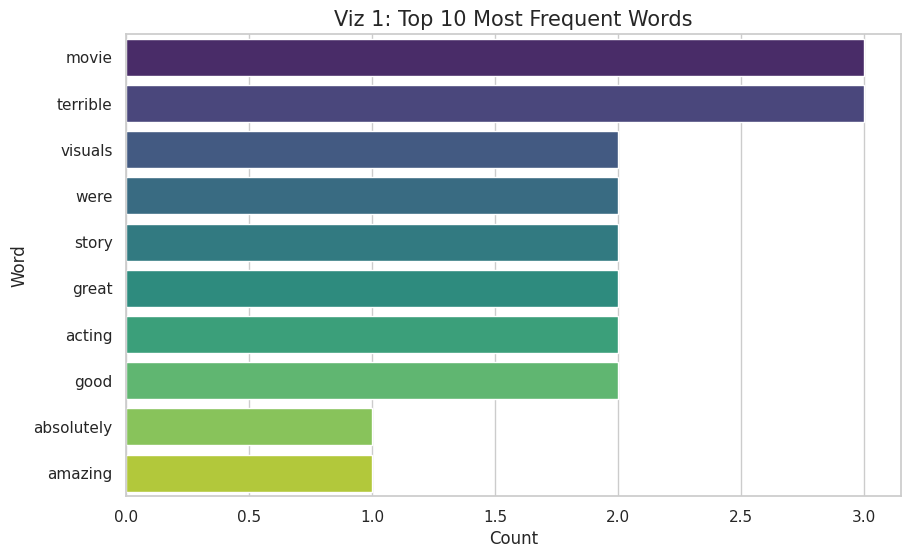

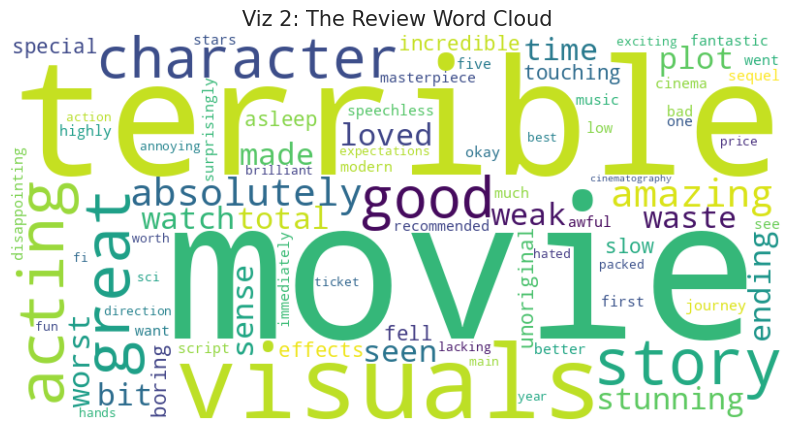

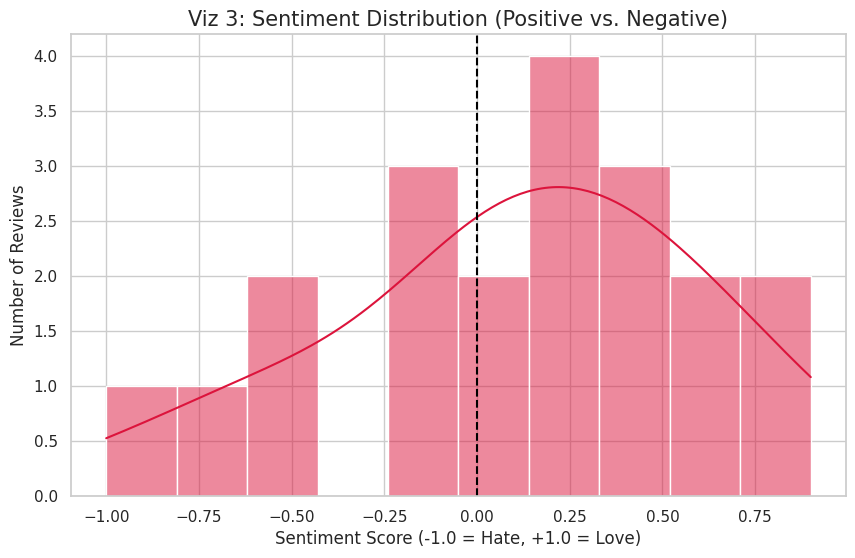

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from textblob import TextBlob
from collections import Counter
import re

# 1. Create the Dataset (The "Text Data")
data = {
    'Review': [
        "This movie was absolutely amazing! The visuals were stunning.",
        "Worst movie I have ever seen. The plot made no sense.",
        "I loved the characters, but the ending was a bit weak.",
        "Total waste of time. Do not watch this.",
        "Incredible special effects and a touching story.",
        "Boring, slow, and unoriginal. I fell asleep.",
        "A masterpiece of modern cinema. Highly recommended!",
        "It was okay, not great but not terrible.",
        "The acting was terrible, but the music was good.",
        "I am speechless. What a fantastic journey.",
        "Disappointing sequel. The first one was much better.",
        "Five stars! I want to see it again immediately.",
        "Terrible script, bad acting, just awful.",
        "Surprisingly good! I went in with low expectations.",
        "Visuals were great, but the story was lacking.",
        "Best sci-fi movie of the year. Hands down.",
        "I hated the main character. So annoying.",
        "Fun, action-packed, and exciting.",
        "Not worth the ticket price.",
        "Brilliant direction and cinematography."
    ]
}
df = pd.DataFrame(data)

print("✅ Text Data Created Successfully!")

# Set the style
sns.set_theme(style="whitegrid")

# --- VIZ 1: TOP 10 MOST COMMON WORDS (Bar Chart) ---
# Clean the text (remove punctuation, lowercase)
all_text = " ".join(df['Review']).lower()
cleaned_text = re.sub(r'[^\w\s]', '', all_text)

# Count words (excluding common stop words manually)
stop_words = set(['the', 'was', 'and', 'i', 'a', 'to', 'of', 'it', 'but', 'in', 'not', 'this', 'is', 'for'])
words = [w for w in cleaned_text.split() if w not in stop_words]
word_counts = Counter(words).most_common(10)

# Plot
plt.figure(figsize=(10, 6))
words_df = pd.DataFrame(word_counts, columns=['Word', 'Count'])
sns.barplot(x='Count', y='Word', data=words_df, palette='viridis')
plt.title('Viz 1: Top 10 Most Frequent Words', fontsize=15)
plt.show()

# --- VIZ 2: WORD CLOUD (Spatial/Frequency) ---
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off') # Turn off axis numbers
plt.title('Viz 2: The Review Word Cloud', fontsize=15)
plt.show()

# --- VIZ 3: SENTIMENT ANALYSIS (Distribution) ---
# Calculate sentiment (Polarity: -1 is Negative, +1 is Positive)
df['Sentiment'] = df['Review'].apply(lambda x: TextBlob(x).sentiment.polarity)

# Plot Histogram
plt.figure(figsize=(10, 6))
sns.histplot(df['Sentiment'], bins=10, kde=True, color='crimson')
plt.title('Viz 3: Sentiment Distribution (Positive vs. Negative)', fontsize=15)
plt.xlabel('Sentiment Score (-1.0 = Hate, +1.0 = Love)')
plt.ylabel('Number of Reviews')
plt.axvline(0, color='black', linestyle='--') # Add a line at Neutral (0)
plt.show()

Visualization 1: Top 10 Most Frequent Words
"This bar chart identifies the most frequently used words in the reviews, with the length of the bar representing the count. The frequent appearance of words like 'movie', 'story', and 'visuals' indicates that reviewers focused more on the production quality and plot than on the acting or characters."

Visualization 2: The Review Word Cloud
"This word cloud provides a spatial representation of the text data, where the size of each word corresponds to its frequency in the dataset. It highlights a mix of strong opposing adjectives like 'amazing' and 'terrible,' suggesting the film was polarizing and elicited strong emotional responses from the audience."

Visualization 3: Sentiment Distribution
"This histogram displays the distribution of sentiment scores calculated by the TextBlob algorithm, ranging from -1.0 (Negative) to +1.0 (Positive). The graph reveals a bimodal distribution with peaks at both extremes, confirming that this was a 'love it or hate it' movie with very few neutral opinions."